<a href="https://colab.research.google.com/github/sswaathiii/Data-Analysis/blob/main/Project_Valuation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT VALUATION ANALYSIS**

***Logo for Project Valuation Analysis***

Saving Project Analysis.jpeg to Project Analysis (1).jpeg


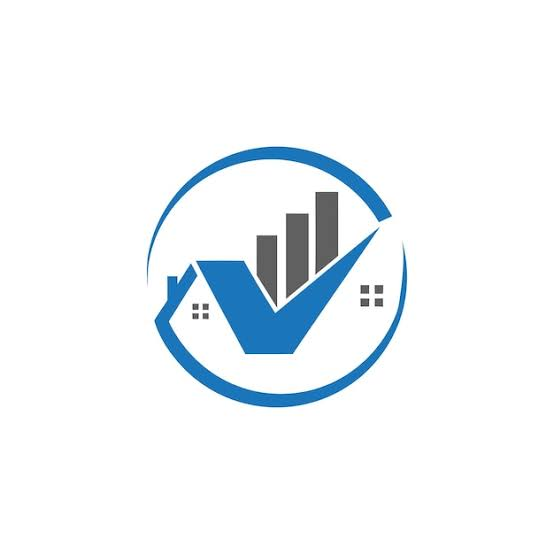

In [ ]:
from google.colab import files
from IPython.display import Image

# This will open a 'Choose File' button
uploaded = files.upload()

# Replace 'your_image.png' with your actual filename
Image('/content/Project Analysis.jpeg', width=300)

**Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


In [ ]:
data = pd.read_csv('/content/Project Analysis.csv')
raw_df = pd.read_csv('/content/Project Analysis.csv')
df = raw_df.copy()

In [ ]:
data.head()

,Project_ID,Project_Name,Category,Start_Date,End_Date,Initial_Investment,Total_Cost,Total_Revenue,Project_Duration_Months,Project_Status,Risk_Level,Profit,ROI_Percentage,Discount_Ratio,NPV,IRP,Net_Cashflow,Annual_Invest
0,P001,Uber Trip Analysis,Data Analytics,10-01-2021,15-06-2021,118619,188163,340205,6,Ongoing,High,152042,80.80,0.1,112387,12.4,2003445,5065345
1,P002,Ecommerce Sales Analysis,Ecommerce,10-02-2021,15-07-2021,196568,72155,158617,6,Completed,High,86462,119.83,0.1,112390,15.4,2003449,5065349
2,P003,Supermarket Sales Analysis,Retail,10-03-2021,15-08-2021,67832,231879,239071,6,Completed,Medium,7192,3.10,1.1,112393,18.4,2003453,5065353
3,P004,Stock Market Analysis,Finance,10-04-2021,15-09-2021,132571,204964,105561,6,Ongoing,High,-99403,-48.50,3.3,112396,21.4,2003457,5065357
4,P005,Customer Churn Analysis,Data Science,10-05-2021,15-10-2021,196677,88253,299520,6,Completed,Medium,211267,239.39,2.1,112399,24.4,2003461,5065361


In [ ]:
data.index

RangeIndex(start=0, stop=50, step=1)

In [ ]:
data.columns


Index(['Project_ID', 'Project_Name', 'Category', 'Start_Date', 'End_Date',
       'Initial_Investment', 'Total_Cost', 'Total_Revenue',
       'Project_Duration_Months', 'Project_Status', 'Risk_Level', 'Profit',
       'ROI_Percentage', 'Discount_Ratio', 'NPV', 'IRP', 'Net_Cashflow',
       'Annual_Invest'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project_ID               50 non-null     object 
 1   Project_Name             50 non-null     object 
 2   Category                 50 non-null     object 
 3   Start_Date               50 non-null     object 
 4   End_Date                 50 non-null     object 
 5   Initial_Investment       50 non-null     int64  
 6   Total_Cost               50 non-null     int64  
 7   Total_Revenue            50 non-null     int64  
 8   Project_Duration_Months  50 non-null     int64  
 9   Project_Status           50 non-null     object 
 10  Risk_Level               50 non-null     object 
 11  Profit                   50 non-null     int64  
 12  ROI_Percentage           50 non-null     float64
 13  Discount_Ratio           50 non-null     float64
 14  NPV                      50 

**Data Cleaning**

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Handle missing data (e.g., fill with median or drop)
df['Total_Cost'] = df['NPV'].fillna(df['Net_Cashflow'].median())

# Remove duplicates
df = df.drop_duplicates()



Project_ID                 0
Project_Name               0
Category                   0
Start_Date                 0
End_Date                   0
Initial_Investment         0
Total_Cost                 0
Total_Revenue              0
Project_Duration_Months    0
Project_Status             0
Risk_Level                 0
Profit                     0
ROI_Percentage             0
Discount_Ratio             0
NPV                        0
IRP                        0
Net_Cashflow               0
Annual_Invest              0
dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Load the dataset
data = pd.read_csv('/content/Project Analysis.csv')


**Data Preparation**

In [ ]:
# Handle missing values
data = data.dropna()
# Convert categorical columns to numerical (if any)
data = pd.get_dummies(data, drop_first=True)
# Split the data into features and target variable
X =data.drop('Initial_Investment', axis=1)
y = data['Total_Cost']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Exploratory Data Analysis (EDA)**

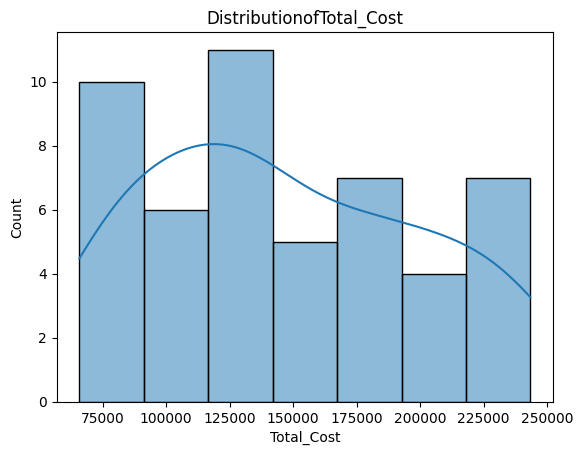

In [ ]:
#Visualizethedistributionof thetargetvariable
sns.histplot(y,kde=True)
plt.title('DistributionofTotal_Cost')
plt.show()


**Bivariate & Multivariate Analysis**

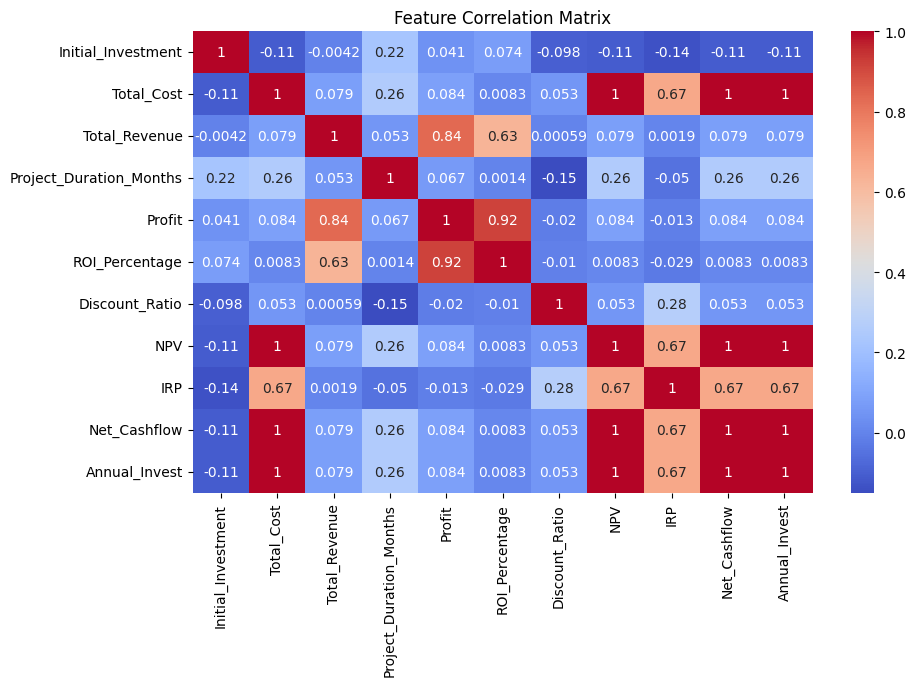

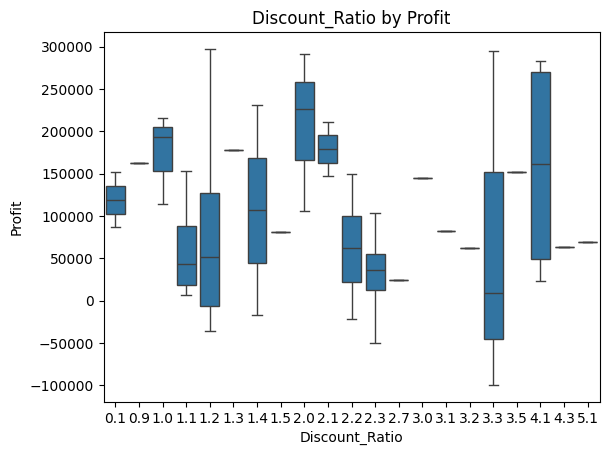

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Box Plot: Survival status by age
sns.boxplot(x='Discount_Ratio', y='Profit', data=df)
plt.title('Discount_Ratio by Profit')
plt.show()


**Outlier Detection**


In [ ]:
# Detecting outliers for 'fare'
Q1 = df['Total_Revenue'].quantile(0.25)
Q3 = df['Total_Revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Total_Revenue'] < (Q1 - 1.5 * IQR)) | (df['Total_Revenue'] > (Q3 + 1.5 * IQR))]
print(f"Total outliers detected: {len(outliers)}")


Total outliers detected: 0


 **Histogram for NPV distribution**

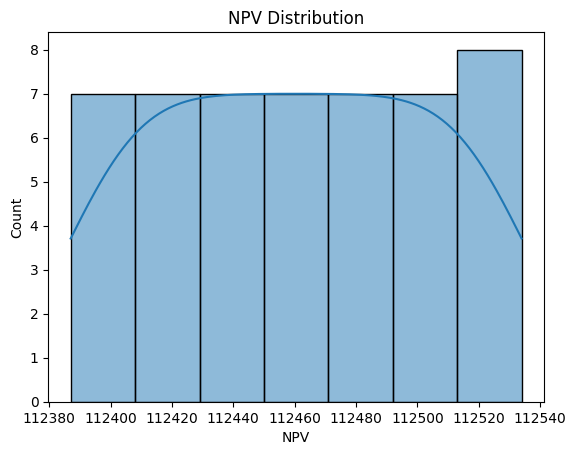

In [ ]:
# Histogram for distribution
sns.histplot(df['NPV'], kde=True)
plt.title('NPV Distribution')
plt.show()




**Multivariate Analysis**

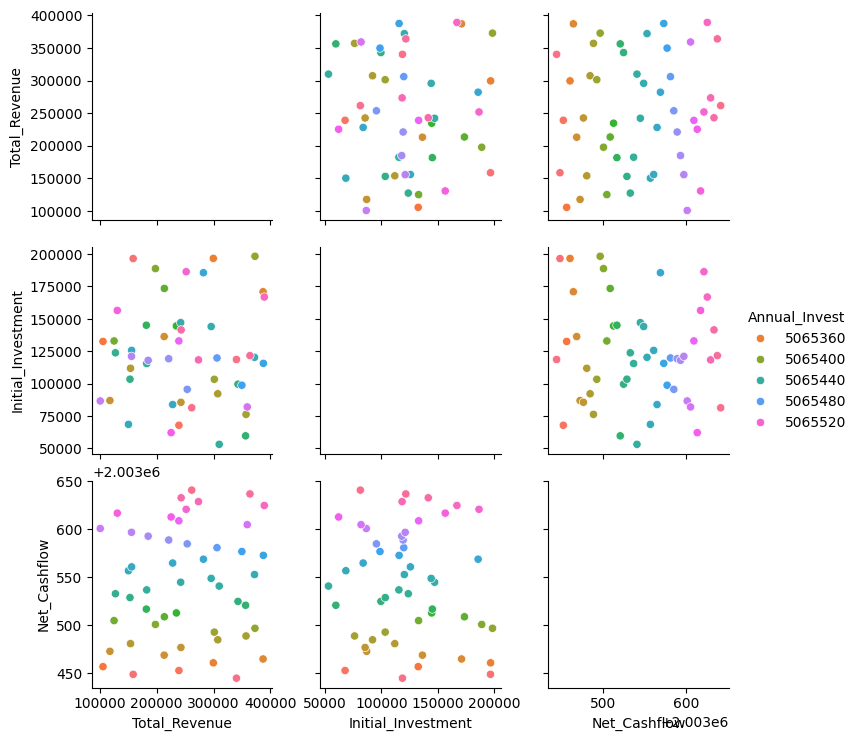

In [ ]:
# Pairwise relationships colored by a specific label
sns.pairplot(df[['Total_Revenue', 'Initial_Investment', 'Net_Cashflow', 'Annual_Invest']], hue='Annual_Invest', palette='husl')
plt.show()


**Model Selection and Training**

In [ ]:
#InitializetheLinearRegressionmodel
lr_model=LinearRegression()
#Trainthemodelonthetrainingdata
lr_model.fit(X_train,y_train)
#Makepredictionsonthetestingdata
y_pred_lr=lr_model.predict(X_test)
#InitializetheRandomForestRegressormodel
rf_model=RandomForestRegressor(random_state=42)
#Trainthemodelonthetrainingdata
rf_model.fit(X_train,y_train)
#Makepredictionsonthetestingdata
y_pred_rf=rf_model.predict(X_test)

**Model Evaluation**

In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f'Linear Regression Mean Squared Error: {mse_lr}')
print(f'Linear Regression R-squared: {r2_lr}')
# Evaluate the Random Forest model's performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Mean Squared Error: {mse_rf}')
print(f'Random Forest R-squared: {r2_rf}')

Linear Regression Mean Squared Error: 1532260808.0814736
Linear Regression R-squared: 0.350419214902544
Random Forest Mean Squared Error: 26449990.653210007
Random Forest R-squared: 0.9887868921506613


In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)



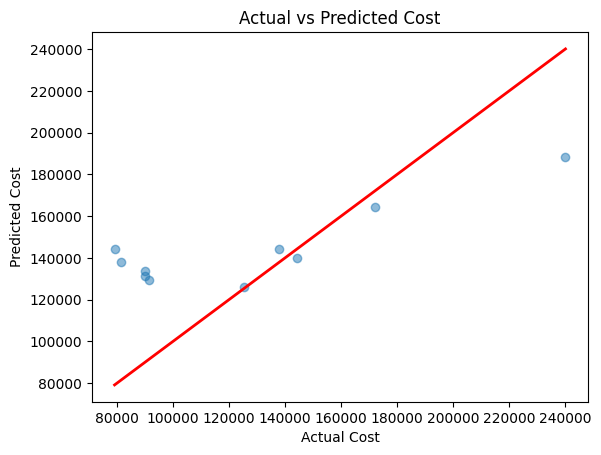

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs Predicted Cost')
plt.show()

**Profit Over Time**

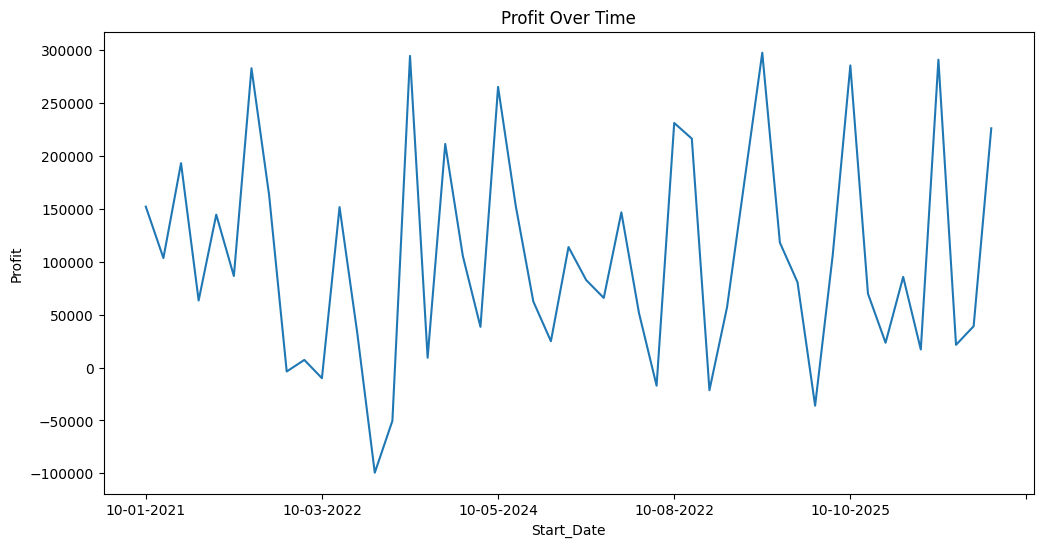

In [ ]:
plt.figure(figsize=(12, 6))
data.groupby('Start_Date')['Profit'].sum().plot()
plt.title('Profit Over Time')
plt.xlabel('Start_Date')
plt.ylabel('Profit')
plt.show()

**Category  Distribution by Revenue**

/tmp/ipython-input-343140607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total_Revenue', y='Category', data=data, palette='Set2')


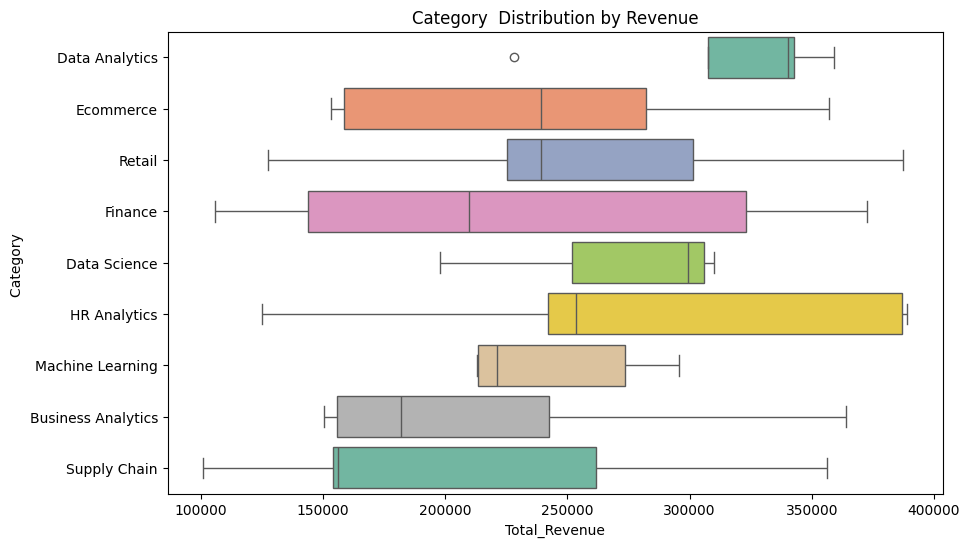

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Total_Revenue', y='Category', data=data, palette='Set2')
plt.title('Category  Distribution by Revenue')
plt.xlabel('Total_Revenue')
plt.ylabel('Category ')
plt.show()

**NPV Profile Analysis**

In [ ]:
pip install numpy-financial

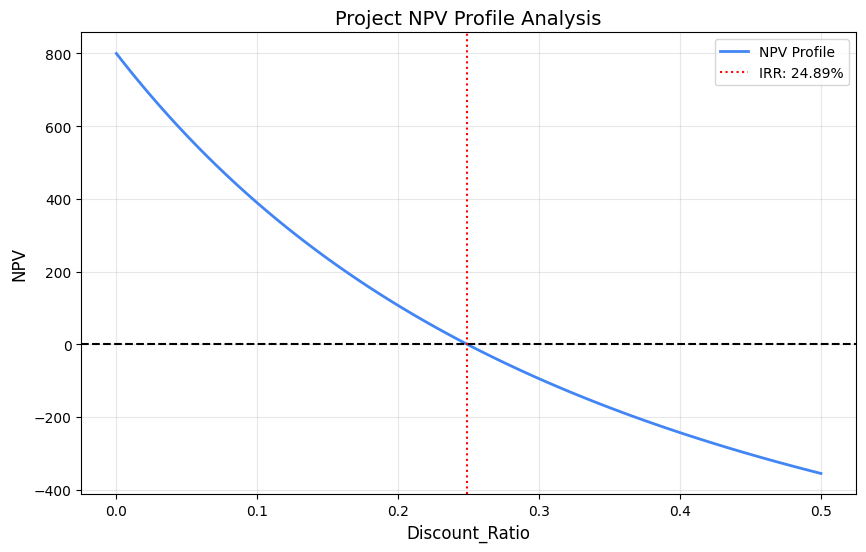

In [ ]:
import numpy_financial as npf
import matplotlib.pyplot as plt
import numpy as np

# Define project cash flows (Initial investment followed by annual returns)
cash_flows = [-1000, 300, 400, 500, 600]
discount_rates = np.linspace(0, 0.5, 100)  # Rates from 0% to 50%

# Calculate NPV for each rate
npv_values = [npf.npv(rate, cash_flows) for rate in discount_rates]
project_irr = npf.irr(cash_flows)

plt.figure(figsize=(10, 6))
plt.plot(discount_rates, npv_values, label='NPV Profile', color='#4285F4', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(project_irr, color='red', linestyle=':', label=f'IRR: {project_irr:.2%}')

plt.title('Project NPV Profile Analysis', fontsize=14)
plt.xlabel('Discount_Ratio', fontsize=12)
plt.ylabel('NPV', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Monte Carlo Simulation for Risk Assessment**

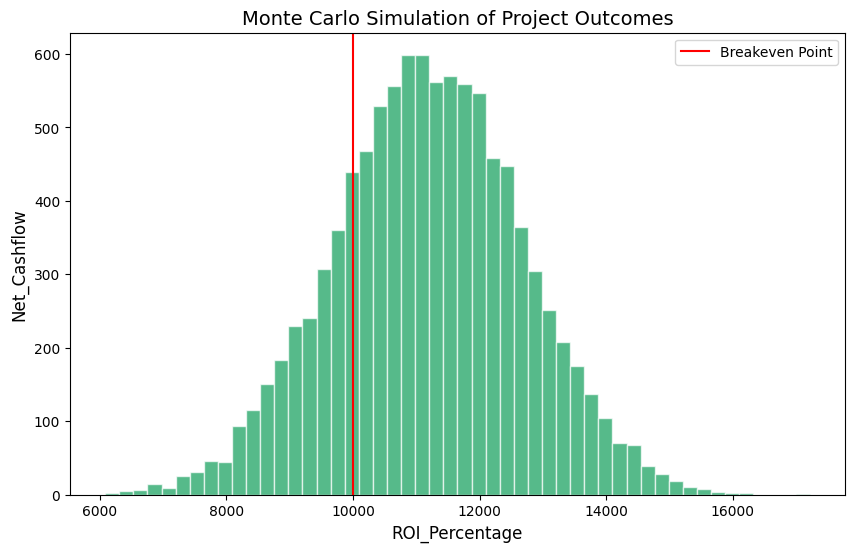

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
simulations = 10000
mean_return = 0.12  # Expected 12% return
std_dev = 0.15     # 15% volatility
initial_investment = 10000

# Generate random outcomes
results = np.random.normal(mean_return, std_dev, simulations)
final_values = initial_investment * (1 + results)

plt.figure(figsize=(10, 6))
plt.hist(final_values, bins=50, color='#0F9D58', edgecolor='white', alpha=0.7)
plt.axvline(initial_investment, color='red', label='Breakeven Point')

plt.title('Monte Carlo Simulation of Project Outcomes', fontsize=14)
plt.xlabel('ROI_Percentage', fontsize=12)
plt.ylabel('Net_Cashflow', fontsize=12)
plt.legend()
plt.show()


**Project Cash Flow Waterfall**

In [ ]:
pip install waterfallcharts

  Preparing metadata (setup.py) ... done
  Created wheel for waterfallcharts: filename=waterfallcharts-3.8-py3-none-any.whl size=3388 sha256=aafdbc26655b2971edd92e661ec3b415f8bb2c048d5dbf876690ddc415acbaf0
  Stored in directory: /root/.cache/pip/wheels/9e/09/46/98e54ba4470957768e604c889f6f461c574785086e43f4843e
Successfully built waterfallcharts


/usr/local/lib/python3.12/dist-packages/waterfall_chart.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#29EA38' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trans.loc[trans['positive'] == 1, 'color'] = green_color
/usr/local/lib/python3.12/dist-packages/waterfall_chart.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop] + row['amount']
/usr/local/lib/python3.12/dist-packages/waterfall_chart.py:139: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop]


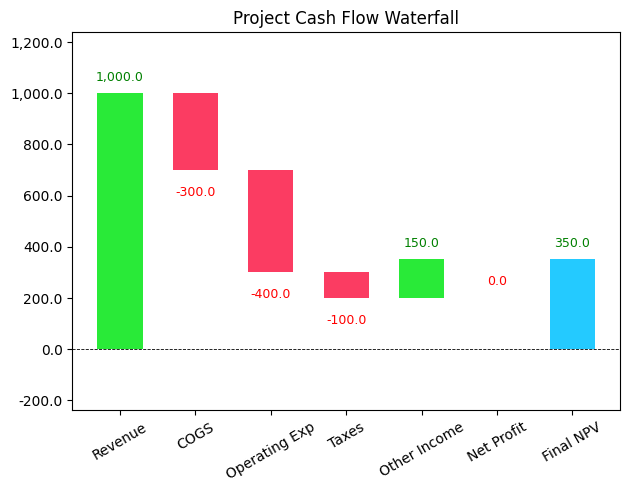

In [ ]:
import waterfall_chart
import matplotlib.pyplot as plt

# Data representing starting revenue, various expenses (negative), and other income (positive)
labels = ['Revenue', 'COGS', 'Operating Exp', 'Taxes', 'Other Income', 'Net Profit']
values = [1000, -300, -400, -100, 150, 0] # Last value typically set to 0 for auto-calculation

# The plot function automatically calculates the 'net' total
waterfall_chart.plot(labels, values, net_label="Final NPV")
plt.title("Project Cash Flow Waterfall")
plt.show()


**NPV Sensitivity Tornado Diagram**

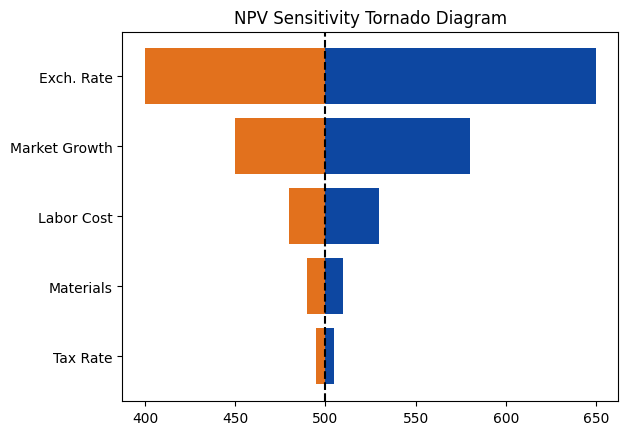

In [ ]:
import matplotlib.pyplot as plt

variables = ['Exch. Rate', 'Market Growth', 'Labor Cost', 'Materials', 'Tax Rate']
base_npv = 500  # The baseline NPV
low_impact = [400, 450, 480, 490, 495]  # NPV if variable is at its 'low'
high_impact = [650, 580, 530, 510, 505] # NPV if variable is at its 'high'

fig, ax = plt.subplots()
for i, var in enumerate(variables):
    # Calculate widths relative to the baseline
    ax.broken_barh([(low_impact[i], base_npv - low_impact[i]),
                    (base_npv, high_impact[i] - base_npv)],
                   (i - 0.4, 0.8), facecolors=('#e2711d', '#0d47a1'))

ax.axvline(base_npv, color='black', linestyle='--', label='Baseline NPV')
ax.set_yticks(range(len(variables)))
ax.set_yticklabels(variables)
ax.invert_yaxis() # Put most impactful (widest ranges) at top if sorted
plt.title("NPV Sensitivity Tornado Diagram")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv('/content/Project Analysis.csv')
df = pd.DataFrame(data)



**Represent Final Data**

In [ ]:
rep_data = pd.DataFrame(index = ['Total_Cost','Profit','Discount_Ratio','Annual_Invest'],
                     data = [data['Total_Cost'].mean(),data['Profit'].mean(),
                             data['Discount_Ratio'].mean(),data['Annual_Invest'].value_counts().index[0]])
rep_data

,0
Total_Cost,146648.200
Profit,102212.840
Discount_Ratio,2.126
Annual_Invest,5065345.000
